<a href="https://colab.research.google.com/github/nithinbadicodes/AI-ML-Projects/blob/master/Diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Diabetes Prediction

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('diabetes_data.csv')
df.head().T

,0,1,2,3,4
Pregnancies,2.000,0.000,0.00,0.000,1.000
Glucose,138.000,84.000,145.00,135.000,139.000
BloodPressure,62.000,82.000,0.00,68.000,62.000
SkinThickness,35.000,31.000,0.00,42.000,41.000
Insulin,0.000,125.000,0.00,250.000,480.000
BMI,33.600,38.200,44.20,42.300,40.700
DiabetesPedigreeFunction,0.127,0.233,0.63,0.365,0.536
Age,47.000,23.000,31.00,24.000,21.000
Outcome,1.000,0.000,1.00,1.000,0.000


### Exploring the dataset

In [3]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,2000.0,3.70350,3.306063,0.000,1.000,3.000,6.000,17.00
Glucose,2000.0,121.18250,32.068636,0.000,99.000,117.000,141.000,199.00
BloodPressure,2000.0,69.14550,19.188315,0.000,63.500,72.000,80.000,122.00
SkinThickness,2000.0,20.93500,16.103243,0.000,0.000,23.000,32.000,110.00
Insulin,2000.0,80.25400,111.180534,0.000,0.000,40.000,130.000,744.00
BMI,2000.0,32.19300,8.149901,0.000,27.375,32.300,36.800,80.60
DiabetesPedigreeFunction,2000.0,0.47093,0.323553,0.078,0.244,0.376,0.624,2.42
Age,2000.0,33.09050,11.786423,21.000,24.000,29.000,40.000,81.00
Outcome,2000.0,0.34200,0.474498,0.000,0.000,0.000,1.000,1.00


In [5]:
df.isnull().any()

,0
Pregnancies,False
Glucose,False
BloodPressure,False
SkinThickness,False
Insulin,False
BMI,False
DiabetesPedigreeFunction,False
Age,False
Outcome,False


In [6]:
df = df.rename(columns={'DiabetesPedigreeFunction':'DPF'})
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


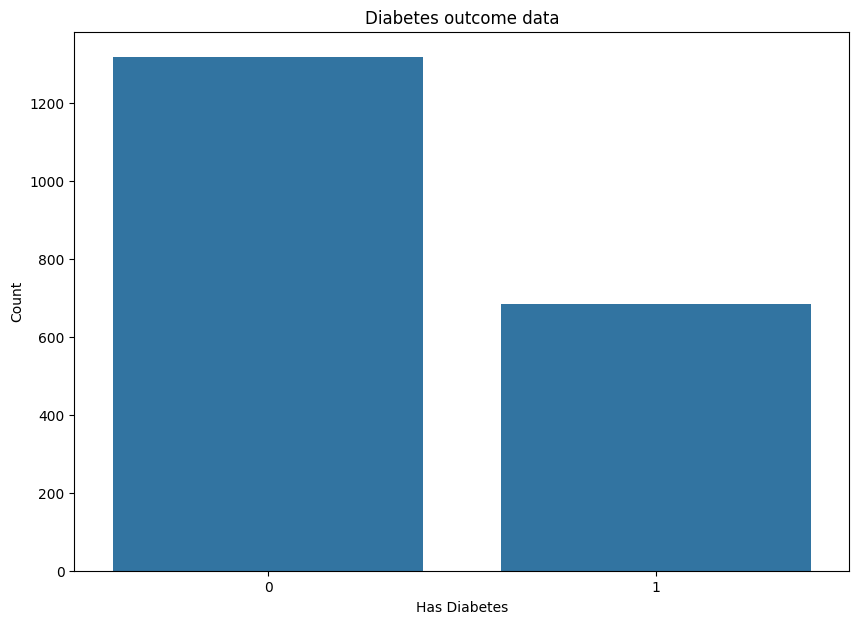

In [12]:
plt.figure(figsize=(10,7))
sns.countplot(data=df,x='Outcome')
plt.xlabel('Has Diabetes')
plt.ylabel('Count')
plt.title('Diabetes outcome data')
plt.show()

## Data Cleaning

> If any of the columns- Glucose, BloodPressure, SkinThickness, Insulin, BMI, age - are 0, it would not make sense. Hence we will replace them with `np.nan` and deal with the missing data.

In [16]:
df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI','Age']].replace(0,np.nan).isnull().sum()

,0
Glucose,13
BloodPressure,90
SkinThickness,573
Insulin,956
BMI,28
Age,0


In [19]:
df_copy = df.copy(deep=True)
df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI','Age']] = df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI','Age']].replace(0,np.nan)
df_copy.isnull().sum()

,0
Pregnancies,0
Glucose,13
BloodPressure,90
SkinThickness,573
Insulin,956
BMI,28
DPF,0
Age,0
Outcome,0


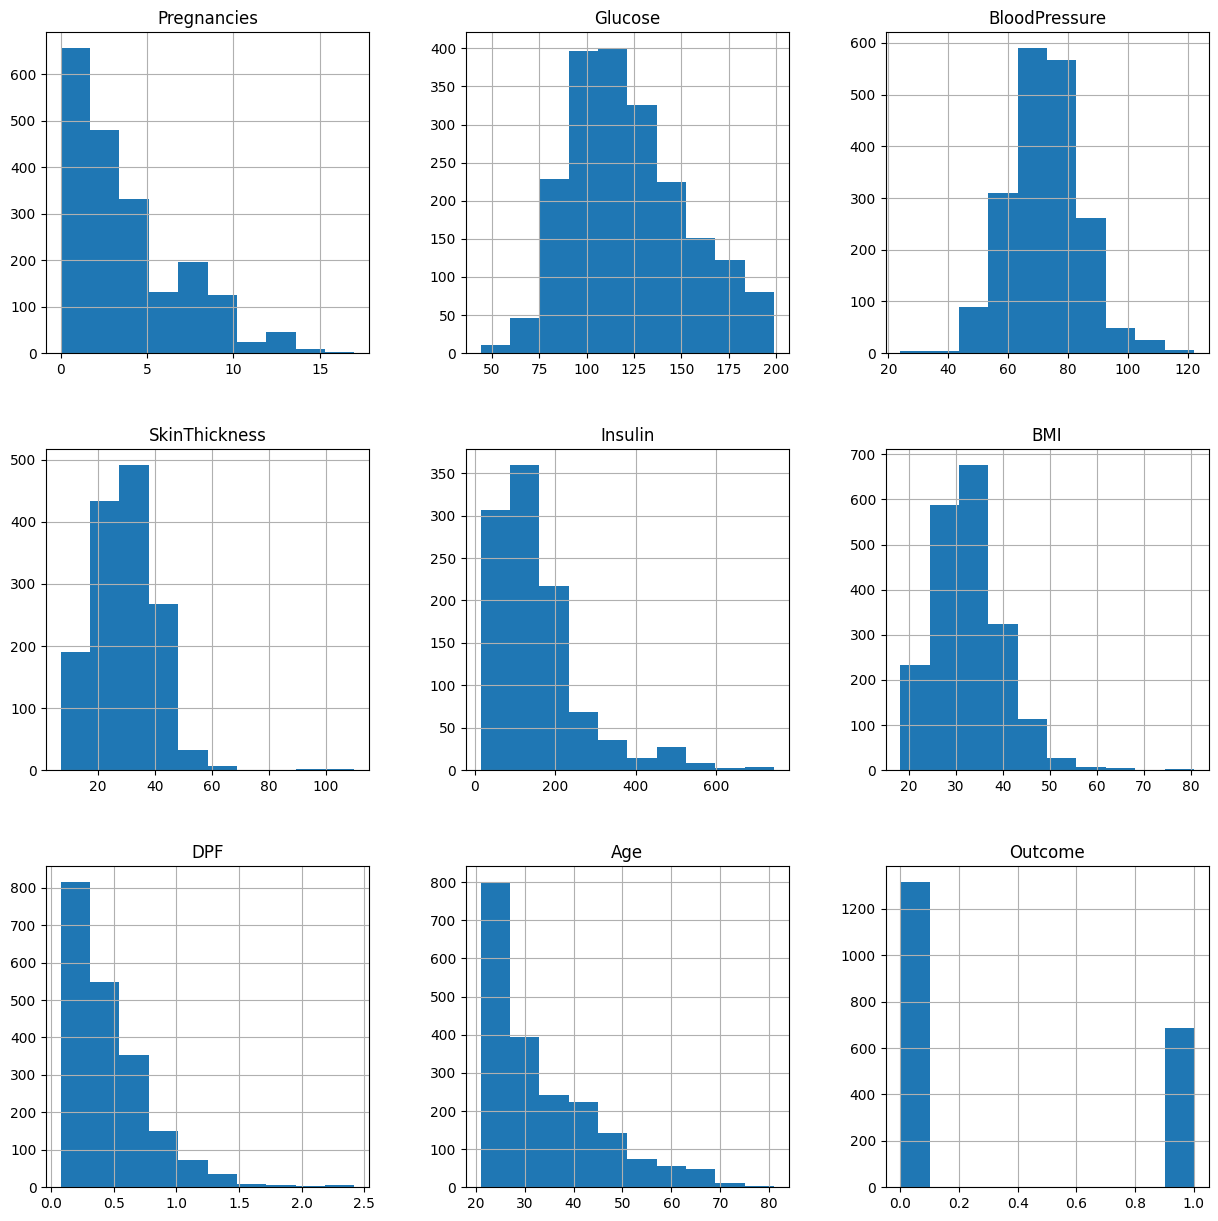

In [20]:
# Plotting histogram of dataset before replacing NaN values
p = df_copy.hist(figsize = (15,15))

* Blood pressure cannot be 0 mmHg
* Glucose levels cannot be 0 mg/dL
* BMI cannot be 0

In [21]:
# Replacing NaN value by mean, median depending upon distribution
df_copy['Glucose'].fillna(df_copy['Glucose'].mean(), inplace=True)
df_copy['BloodPressure'].fillna(df_copy['BloodPressure'].mean(), inplace=True)
df_copy['SkinThickness'].fillna(df_copy['SkinThickness'].median(), inplace=True)
df_copy['Insulin'].fillna(df_copy['Insulin'].median(), inplace=True)
df_copy['BMI'].fillna(df_copy['BMI'].median(), inplace=True)

/tmp/ipython-input-587404965.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Glucose'].fillna(df_copy['Glucose'].mean(), inplace=True)
/tmp/ipython-input-587404965.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

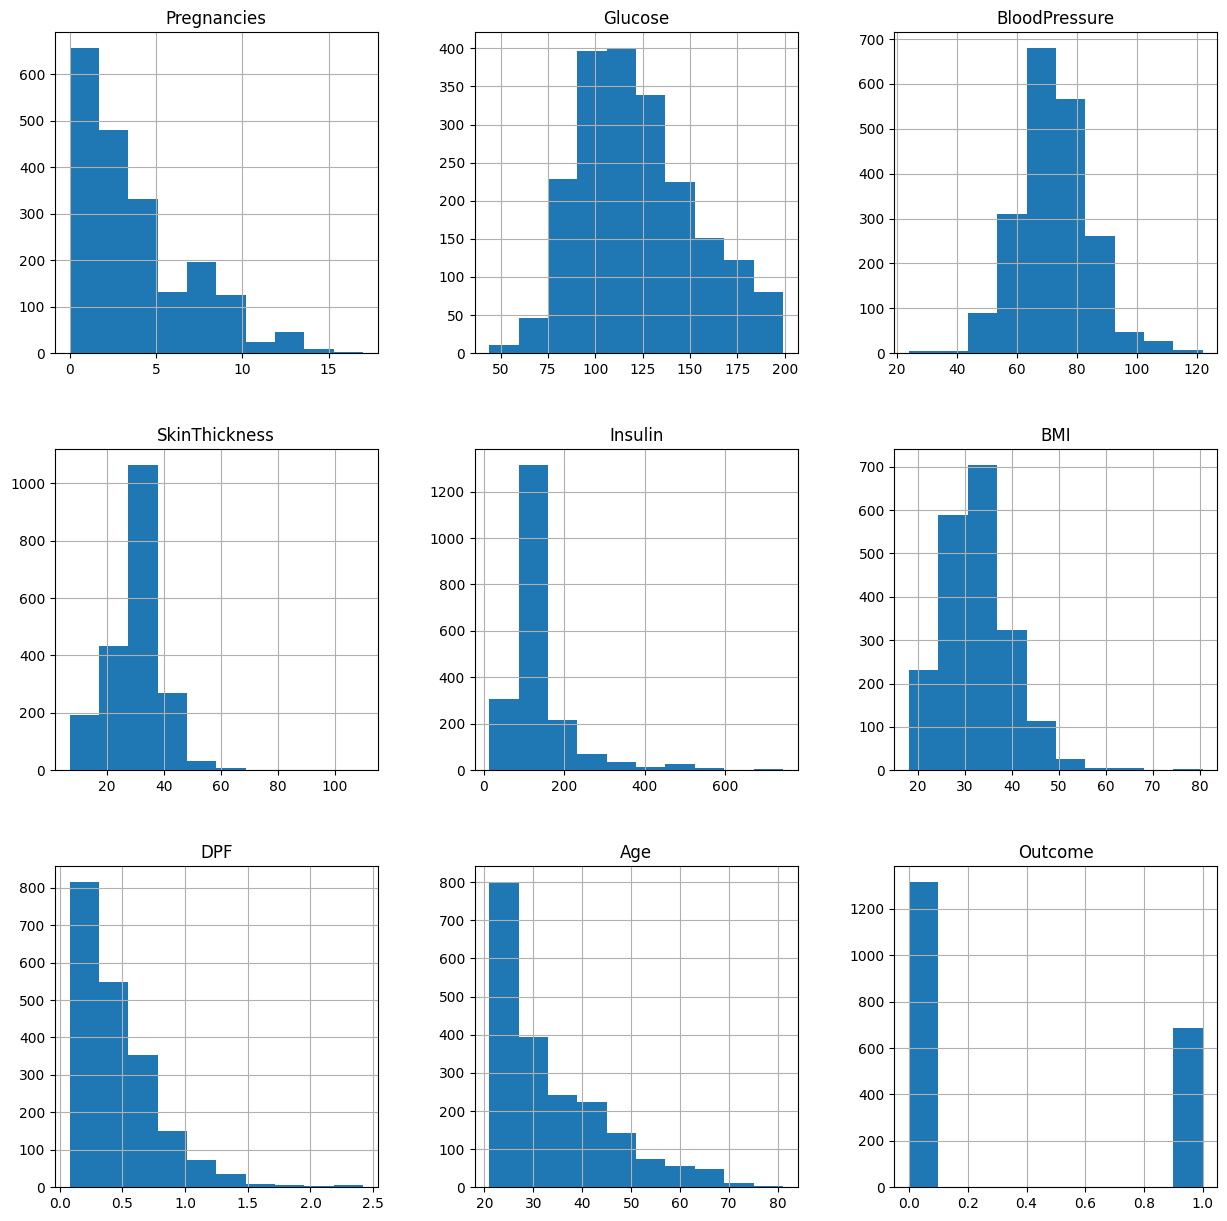

In [22]:
# Plotting histogram of dataset after replacing NaN values
p = df_copy.hist(figsize=(15,15))